In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMForecaster:
    def __init__(self, data_path, window_sizes=[10, 20, 30], hidden_sizes=[32, 64, 128], 
                 num_layers_list=[1, 2, 3], epochs=100, batch_size=32, lr=0.001, 
                 results_dir='results'):
        self.data_path = data_path
        self.window_sizes = window_sizes
        self.hidden_sizes = hidden_sizes
        self.num_layers_list = num_layers_list
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.results_dir = results_dir
        os.makedirs(self.results_dir, exist_ok=True)
        
        self.load_and_normalize_data()
        
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = out[:, -1, :]
            out = self.fc(out)
            return out
    
    def load_and_normalize_data(self):
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        train_size = int(len(data) * 0.7)
        self.train_data = data[:train_size]
        self.test_data = data[train_size:]
        self.global_mean = self.train_data.mean()
        self.global_std = self.train_data.std()
        
    def prepare_data(self, window_size):
        train_data = (self.train_data - self.global_mean) / self.global_std
        test_data = (self.test_data - self.global_mean) / self.global_std
        
        extended_test_data = np.concatenate([
            train_data[-(window_size-1):], 
            test_data
        ])
        
        def create_samples(dataset):
            X, y = [], []
            for i in range(len(dataset)-window_size):
                X.append(dataset[i:i+window_size])
                y.append(dataset[i+window_size])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(extended_test_data)
        
        return (
            torch.from_numpy(X_train).float().view(-1, window_size, 1),
            torch.from_numpy(y_train).float().view(-1, 1),
            torch.from_numpy(X_test).float().view(-1, window_size, 1),
            torch.from_numpy(y_test).float().view(-1, 1)
        )

    def train_model(self, window_size, hidden_size, num_layers):
        X_train, y_train, X_test, y_test = self.prepare_data(window_size)
        
        model = self.LSTMModel(1, hidden_size, num_layers).to(self.device)
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        
        train_dataset = TimeSeriesDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        config_str = f"ws{window_size}_hs{hidden_size}_nl{num_layers}"
        train_losses = []
        test_mses = []
        
        model.train()
        for epoch in tqdm(range(self.epochs), desc=f"WS{window_size} HS{hidden_size} L{num_layers}"):
            epoch_loss = 0
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_loss)
            
            if (epoch + 1) % 10 == 0 or epoch == self.epochs - 1:
                model.eval()
                with torch.no_grad():
                    test_mse = self.evaluate_model(model, X_test, y_test)
                test_mses.append(test_mse)
                model.train()
        
        self.save_results(config_str, model, train_losses, test_mses, X_test, y_test)
        
        return train_losses, test_mses[-1]

    def evaluate_model(self, model, X_test, y_test):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        return np.mean((predictions - actuals) ** 2)

    def save_results(self, config_str, model, train_losses, test_mses, X_test, y_test):
        config_dir = os.path.join(self.results_dir, config_str)
        os.makedirs(config_dir, exist_ok=True)
        
        loss_file = os.path.join(config_dir, 'training_losses.csv')
        pd.DataFrame({
            'epoch': range(1, len(train_losses)+1),
            'loss': train_losses
        }).to_csv(loss_file, index=False)
        
        test_mse_file = os.path.join(config_dir, 'test_mses.csv')
        pd.DataFrame({
            'epoch': [10*(i+1) for i in range(len(test_mses))],
            'test_mse': test_mses
        }).to_csv(test_mse_file, index=False)
        
        model_file = os.path.join(config_dir, 'model.pth')
        torch.save(model.state_dict(), model_file)
        
        self.generate_prediction_plot(model, X_test, y_test, config_str, config_dir)
        
        with open(os.path.join(config_dir, 'config_summary.txt'), 'w') as f:
            f.write(f"Window Size: {config_str.split('_')[0][2:]}\n")
            f.write(f"Hidden Size: {config_str.split('_')[1][2:]}\n")
            f.write(f"Num Layers: {config_str.split('_')[2][2:]}\n")
            f.write(f"Final Training Loss: {train_losses[-1]:.4f}\n")
            f.write(f"Final Test MSE: {test_mses[-1]:.4f}\n")

    def generate_prediction_plot(self, model, X_test, y_test, config_str, config_dir):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        
        plt.figure(figsize=(12, 6))
        plt.plot(actuals, label='Actual', alpha=0.7)
        plt.plot(predictions, label='Predicted', alpha=0.7)
        plt.title(f'Predictions vs Actual - {config_str}')
        plt.legend()
        plot_file = os.path.join(config_dir, 'predictions_vs_actual.png')
        plt.savefig(plot_file)
        plt.close()

    def run_experiments(self):
        results = []
        
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                for nl in self.num_layers_list:
                    print(f"\nTraining model with WS={ws}, HS={hs}, Layers={nl}")
                    config_str = f"ws{ws}_hs{hs}_nl{nl}"
                    
                    try:
                        final_loss, final_mse = self.train_model(ws, hs, nl)
                        results.append({
                            'window_size': ws,
                            'hidden_size': hs,
                            'num_layers': nl,
                            'final_train_loss': final_loss[-1],
                            'final_test_mse': final_mse
                        })
                    except Exception as e:
                        print(f"Failed to train {config_str}: {str(e)}")
                        continue
        
        results_df = pd.DataFrame(results)
        results_file = os.path.join(self.results_dir, 'comparative_results.csv')
        results_df.to_csv(results_file, index=False)
        
        self.generate_comparison_plots(results_df)
        
        return results_df

    def generate_comparison_plots(self, results_df):
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        for hs in self.hidden_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['hidden_size'] == hs) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['window_size'], subset['final_train_loss'], 
                            'o-', label=f'HS={hs}, L={nl}')
        plt.xlabel('Window Size')
        plt.ylabel('Final Training Loss')
        plt.title('Training Loss by Window Size')
        plt.legend()
        
        plt.subplot(1, 3, 2)
        for ws in self.window_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['hidden_size'], subset['final_train_loss'], 
                            'o-', label=f'WS={ws}, L={nl}')
        plt.xlabel('Hidden Size')
        plt.ylabel('Final Training Loss')
        plt.title('Training Loss by Hidden Size')
        plt.legend()
        
        plt.subplot(1, 3, 3)
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['hidden_size'] == hs)
                ]
                if not subset.empty:
                    plt.plot(subset['num_layers'], subset['final_train_loss'], 
                            'o-', label=f'WS={ws}, HS={hs}')
        plt.xlabel('Number of Layers')
        plt.ylabel('Final Training Loss')
        plt.title('Training Loss by Number of Layers')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.results_dir, 'training_loss_comparison.png'))
        plt.show()
        plt.close()
        
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        for hs in self.hidden_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['hidden_size'] == hs) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['window_size'], subset['final_test_mse'], 
                            'o-', label=f'HS={hs}, L={nl}')
        plt.xlabel('Window Size')
        plt.ylabel('Test MSE')
        plt.title('Test MSE by Window Size')
        plt.legend()
        
        plt.subplot(1, 3, 2)
        for ws in self.window_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['hidden_size'], subset['final_test_mse'], 
                            'o-', label=f'WS={ws}, L={nl}')
        plt.xlabel('Hidden Size')
        plt.ylabel('Test MSE')
        plt.title('Test MSE by Hidden Size')
        plt.legend()
        
        plt.subplot(1, 3, 3)
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['hidden_size'] == hs)
                ]
                if not subset.empty:
                    plt.plot(subset['num_layers'], subset['final_test_mse'], 
                            'o-', label=f'WS={ws}, HS={hs}')
        plt.xlabel('Number of Layers')
        plt.ylabel('Test MSE')
        plt.title('Test MSE by Number of Layers')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.results_dir, 'test_mse_comparison.png'))
        plt.show()
        plt.close()


Training model with WS=10, HS=32, Layers=1


WS10 HS32 L1: 100%|██████████| 100/100 [02:15<00:00,  1.36s/it]



Training model with WS=10, HS=32, Layers=2


WS10 HS32 L2: 100%|██████████| 100/100 [02:40<00:00,  1.61s/it]



Training model with WS=10, HS=32, Layers=3


...

WS30 HS128 L1: 100%|██████████| 100/100 [02:19<00:00,  1.39s/it]



Training model with WS=30, HS=128, Layers=2


WS30 HS128 L2: 100%|██████████| 100/100 [02:44<00:00,  1.64s/it]



Training model with WS=30, HS=128, Layers=3


WS30 HS128 L3: 100%|██████████| 100/100 [03:08<00:00,  1.89s/it]


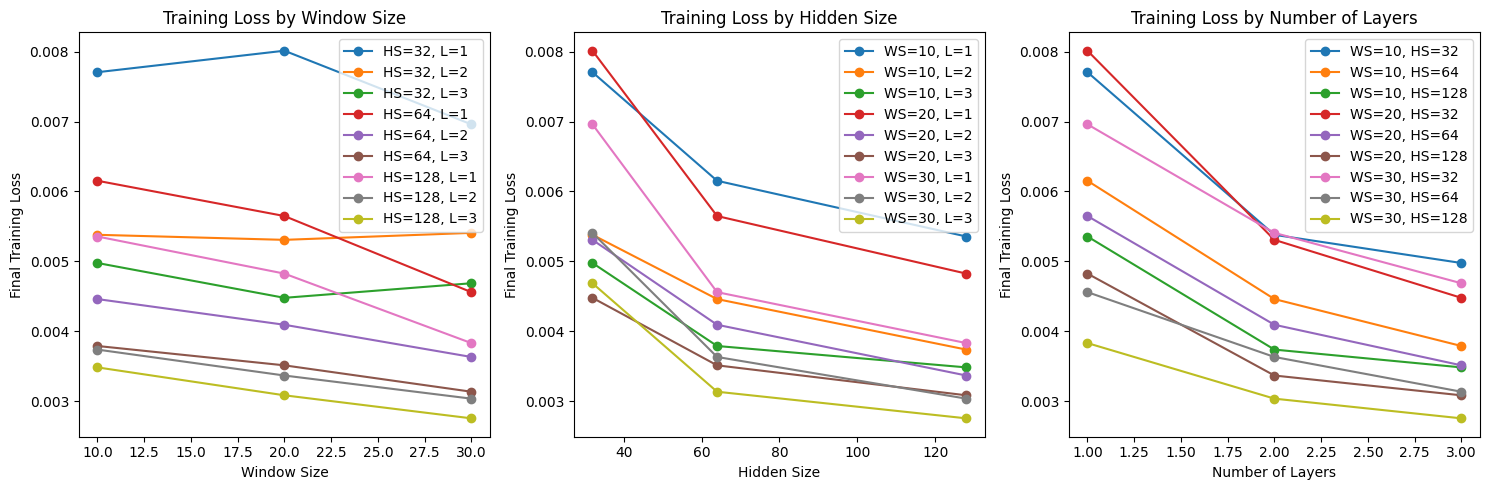

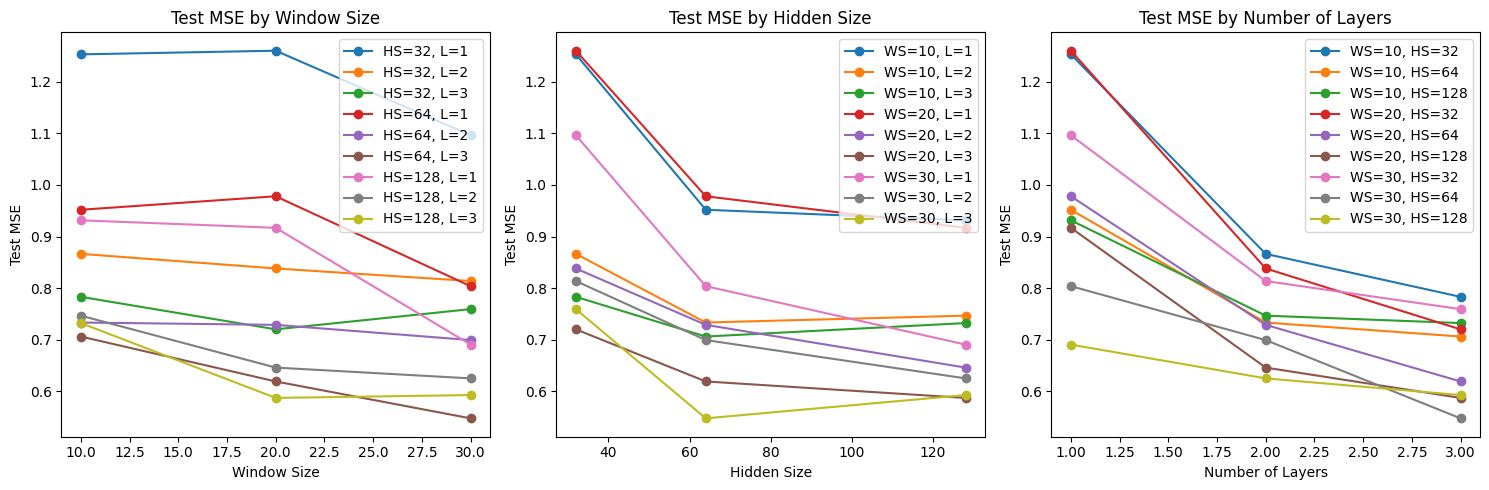


Comparative Results:
 window_size  hidden_size  num_layers  final_train_loss  final_test_mse
          10           32           1          0.007708        1.252957
          10           32           2          0.005380        0.866565
          10           32           3          0.004976        0.783333
          10           64           1          0.006154        0.951991
          10           64           2          0.004460        0.733573
          10           64           3          0.003788        0.706433
          10          128           1          0.005356        0.931531
          10          128           2          0.003736        0.746890
          10          128           3          0.003481        0.732513
          20           32           1          0.008016        1.260028
          20           32           2          0.005307        0.838277
          20           32           3          0.004477        0.720366
          20           64           1     

In [2]:
if __name__ == '__main__':
    data_path = "/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt"  
    
    forecaster = LSTMForecaster(
        data_path=data_path,
        window_sizes=[10, 20, 30],  
        hidden_sizes=[32, 64, 128], 
        num_layers_list=[1, 2, 3],  
        epochs=100,  
        batch_size=32,  
        lr=0.0001,  
        results_dir='lstm_results' 
    )
    
    results = forecaster.run_experiments()
    
    print("\nComparative Results:")
    print(results.to_string(index=False))

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.metrics import mean_squared_error

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MultiStepLSTMForecaster:
    def __init__(self, data_path, window_sizes=[10, 20, 30], hidden_sizes=[32, 64, 128], 
                 num_layers_list=[1, 2, 3], forecast_steps=[1, 3, 5], epochs=100, 
                 batch_size=32, lr=0.001, results_dir='multi_step_results'):
        self.data_path = data_path
        self.window_sizes = window_sizes
        self.hidden_sizes = hidden_sizes
        self.num_layers_list = num_layers_list
        self.forecast_steps = forecast_steps
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.results_dir = results_dir
        os.makedirs(self.results_dir, exist_ok=True)
        
        self.load_and_normalize_data()
        
    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, output_steps=1):
            super().__init__()
            self.output_steps = output_steps
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, output_steps)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = out[:, -1, :] 
            out = self.fc(out)
            return out.view(-1, self.output_steps)
    
    def load_and_normalize_data(self):
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        train_size = int(len(data) * 0.7)
        self.train_data = data[:train_size]
        self.test_data = data[train_size:]
        self.global_mean = self.train_data.mean()
        self.global_std = self.train_data.std()
        
    def prepare_data(self, window_size, forecast_steps):
        train_data = (self.train_data - self.global_mean) / self.global_std
        test_data = (self.test_data - self.global_mean) / self.global_std
        
        extended_test_data = np.concatenate([
            train_data[-(window_size + forecast_steps - 1):], 
            test_data
        ])
        
        def create_samples(dataset):
            X, y = [], []
            for i in range(len(dataset)-window_size-forecast_steps+1):
                X.append(dataset[i:i+window_size])
                y.append(dataset[i+window_size:i+window_size+forecast_steps])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(extended_test_data)
        
        return (
            torch.from_numpy(X_train).float().view(-1, window_size, 1),
            torch.from_numpy(y_train).float().view(-1, forecast_steps),
            torch.from_numpy(X_test).float().view(-1, window_size, 1),
            torch.from_numpy(y_test).float().view(-1, forecast_steps)
        )

    def train_model(self, window_size, hidden_size, num_layers, forecast_steps):
        X_train, y_train, X_test, y_test = self.prepare_data(window_size, forecast_steps)
        
        model = self.LSTMModel(1, hidden_size, num_layers, forecast_steps).to(self.device)
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        
        train_dataset = TimeSeriesDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        config_str = f"ws{window_size}_hs{hidden_size}_nl{num_layers}_fs{forecast_steps}"
        train_losses = []
        test_mses = []
        
        model.train()
        for epoch in tqdm(range(self.epochs), desc=f"WS{window_size} HS{hidden_size} L{num_layers} FS{forecast_steps}"):
            epoch_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_loss)
            
            if (epoch + 1) % 10 == 0 or epoch == self.epochs - 1:
                model.eval()
                with torch.no_grad():
                    test_mse = self.evaluate_model(model, X_test, y_test, forecast_steps)
                test_mses.append(test_mse)
                model.train()
        
        self.save_results(config_str, model, train_losses, test_mses, X_test, y_test, forecast_steps)
        
        return train_losses, test_mses[-1]

    def evaluate_model(self, model, X_test, y_test, forecast_steps):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        
        step_mses = [mean_squared_error(actuals[:, i], predictions[:, i]) 
                    for i in range(forecast_steps)]
        
        return np.mean(step_mses)

    def save_results(self, config_str, model, train_losses, test_mses, X_test, y_test, forecast_steps):
        config_dir = os.path.join(self.results_dir, config_str)
        os.makedirs(config_dir, exist_ok=True)
        
        loss_file = os.path.join(config_dir, 'training_losses.csv')
        pd.DataFrame({
            'epoch': range(1, len(train_losses)+1),
            'loss': train_losses
        }).to_csv(loss_file, index=False)
        
        test_mse_file = os.path.join(config_dir, 'test_mses.csv')
        pd.DataFrame({
            'epoch': [10*(i+1) for i in range(len(test_mses))],
            'test_mse': test_mses
        }).to_csv(test_mse_file, index=False)
        
        model_file = os.path.join(config_dir, 'model.pth')
        torch.save(model.state_dict(), model_file)
        
        self.generate_prediction_plot(model, X_test, y_test, config_str, config_dir, forecast_steps)
        
        with open(os.path.join(config_dir, 'config_summary.txt'), 'w') as f:
            f.write(f"Window Size: {config_str.split('_')[0][2:]}\n")
            f.write(f"Hidden Size: {config_str.split('_')[1][2:]}\n")
            f.write(f"Num Layers: {config_str.split('_')[2][2:]}\n")
            f.write(f"Forecast Steps: {config_str.split('_')[3][2:]}\n")
            f.write(f"Final Training Loss: {train_losses[-1]:.4f}\n")
            f.write(f"Final Test MSE: {test_mses[-1]:.4f}\n")

    def generate_prediction_plot(self, model, X_test, y_test, config_str, config_dir, forecast_steps):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        
        plt.figure(figsize=(15, 5*forecast_steps))
        
        for step in range(forecast_steps):
            plt.subplot(forecast_steps, 1, step+1)
            plt.plot(actuals[:, step], label='Actual', alpha=0.7)
            plt.plot(predictions[:, step], label='Predicted', alpha=0.7)
            plt.title(f'Step {step+1} Predictions vs Actual - {config_str}')
            plt.legend()
        
        plt.tight_layout()
        plot_file = os.path.join(config_dir, 'predictions_vs_actual.png')
        plt.savefig(plot_file)
        plt.close()

    def run_experiments(self):
        results = []
        
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                for nl in self.num_layers_list:
                    for fs in self.forecast_steps:
                        print(f"\nTraining model with WS={ws}, HS={hs}, Layers={nl}, FS={fs}")
                        config_str = f"ws{ws}_hs{hs}_nl{nl}_fs{fs}"
                        
                        try:
                            final_loss, final_mse = self.train_model(ws, hs, nl, fs)
                            results.append({
                                'window_size': ws,
                                'hidden_size': hs,
                                'num_layers': nl,
                                'forecast_steps': fs,
                                'final_train_loss': final_loss[-1],
                                'final_test_mse': final_mse
                            })
                        except Exception as e:
                            print(f"Failed to train {config_str}: {str(e)}")
                            continue
        
        results_df = pd.DataFrame(results)
        results_file = os.path.join(self.results_dir, 'comparative_results.csv')
        results_df.to_csv(results_file, index=False)
        
        self.generate_comparison_plots(results_df)
        
        return results_df

    def generate_comparison_plots(self, results_df):
        for fs in self.forecast_steps:
            plt.figure(figsize=(15, 5))
            plt.suptitle(f'Training Loss Comparison (Forecast Steps={fs})', y=1.05)
            
            plt.subplot(1, 3, 1)
            for hs in self.hidden_sizes:
                for nl in self.num_layers_list:
                    subset = results_df[
                        (results_df['hidden_size'] == hs) & 
                        (results_df['num_layers'] == nl) &
                        (results_df['forecast_steps'] == fs)
                    ]
                    if not subset.empty:
                        plt.plot(subset['window_size'], subset['final_train_loss'], 
                                'o-', label=f'HS={hs}, L={nl}')
            plt.xlabel('Window Size')
            plt.ylabel('Final Training Loss')
            plt.title('By Window Size')
            plt.legend()
            
            plt.subplot(1, 3, 2)
            for ws in self.window_sizes:
                for nl in self.num_layers_list:
                    subset = results_df[
                        (results_df['window_size'] == ws) & 
                        (results_df['num_layers'] == nl) &
                        (results_df['forecast_steps'] == fs)
                    ]
                    if not subset.empty:
                        plt.plot(subset['hidden_size'], subset['final_train_loss'], 
                                'o-', label=f'WS={ws}, L={nl}')
            plt.xlabel('Hidden Size')
            plt.ylabel('Final Training Loss')
            plt.title('By Hidden Size')
            plt.legend()
            
            plt.subplot(1, 3, 3)
            for ws in self.window_sizes:
                for hs in self.hidden_sizes:
                    subset = results_df[
                        (results_df['window_size'] == ws) & 
                        (results_df['hidden_size'] == hs) &
                        (results_df['forecast_steps'] == fs)
                    ]
                    if not subset.empty:
                        plt.plot(subset['num_layers'], subset['final_train_loss'], 
                                'o-', label=f'WS={ws}, HS={hs}')
            plt.xlabel('Number of Layers')
            plt.ylabel('Final Training Loss')
            plt.title('By Number of Layers')
            plt.legend()
            
            plt.tight_layout()
            plt.savefig(os.path.join(self.results_dir, f'training_loss_comparison_fs{fs}.png'))
            plt.show()
            plt.close()
        
        plt.figure(figsize=(15, 5))
        plt.suptitle('Test MSE by Forecast Steps', y=1.05)
        
        plt.subplot(1, 3, 1)
        for ws in self.window_sizes:
            subset = results_df[results_df['window_size'] == ws]
            if not subset.empty:
                for hs in self.hidden_sizes:
                    for nl in self.num_layers_list:
                        config_subset = subset[
                            (subset['hidden_size'] == hs) & 
                            (subset['num_layers'] == nl)
                        ]
                        if not config_subset.empty:
                            plt.plot(config_subset['forecast_steps'], config_subset['final_test_mse'], 
                                    'o-', label=f'WS={ws},HS={hs},L={nl}')
        plt.xlabel('Forecast Steps')
        plt.ylabel('Test MSE')
        plt.title('By Window Size')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.subplot(1, 3, 2)
        for hs in self.hidden_sizes:
            subset = results_df[results_df['hidden_size'] == hs]
            if not subset.empty:
                for ws in self.window_sizes:
                    for nl in self.num_layers_list:
                        config_subset = subset[
                            (subset['window_size'] == ws) & 
                            (subset['num_layers'] == nl)
                        ]
                        if not config_subset.empty:
                            plt.plot(config_subset['forecast_steps'], config_subset['final_test_mse'], 
                                    'o-', label=f'WS={ws},HS={hs},L={nl}')
        plt.xlabel('Forecast Steps')
        plt.ylabel('Test MSE')
        plt.title('By Hidden Size')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.subplot(1, 3, 3)
        for nl in self.num_layers_list:
            subset = results_df[results_df['num_layers'] == nl]
            if not subset.empty:
                for ws in self.window_sizes:
                    for hs in self.hidden_sizes:
                        config_subset = subset[
                            (subset['window_size'] == ws) & 
                            (subset['hidden_size'] == hs)
                        ]
                        if not config_subset.empty:
                            plt.plot(config_subset['forecast_steps'], config_subset['final_test_mse'], 
                                    'o-', label=f'WS={ws},HS={hs},L={nl}')
        plt.xlabel('Forecast Steps')
        plt.ylabel('Test MSE')
        plt.title('By Number of Layers')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.results_dir, 'test_mse_vs_forecast_steps.png'))
        plt.show()
        plt.close()


Training model with WS=20, HS=64, Layers=2, FS=1


WS20 HS64 L2 FS1: 100%|██████████| 100/100 [03:00<00:00,  1.81s/it]



Training model with WS=20, HS=64, Layers=2, FS=3


WS20 HS64 L2 FS3: 100%|██████████| 100/100 [03:00<00:00,  1.80s/it]



Training model with WS=20, HS=64, Layers=2, FS=5


...

WS30 HS128 L3 FS3: 100%|██████████| 100/100 [03:28<00:00,  2.08s/it]



Training model with WS=30, HS=128, Layers=3, FS=5


WS30 HS128 L3 FS5: 100%|██████████| 100/100 [03:29<00:00,  2.10s/it]



Training model with WS=30, HS=128, Layers=3, FS=7


WS30 HS128 L3 FS7: 100%|██████████| 100/100 [03:29<00:00,  2.10s/it]


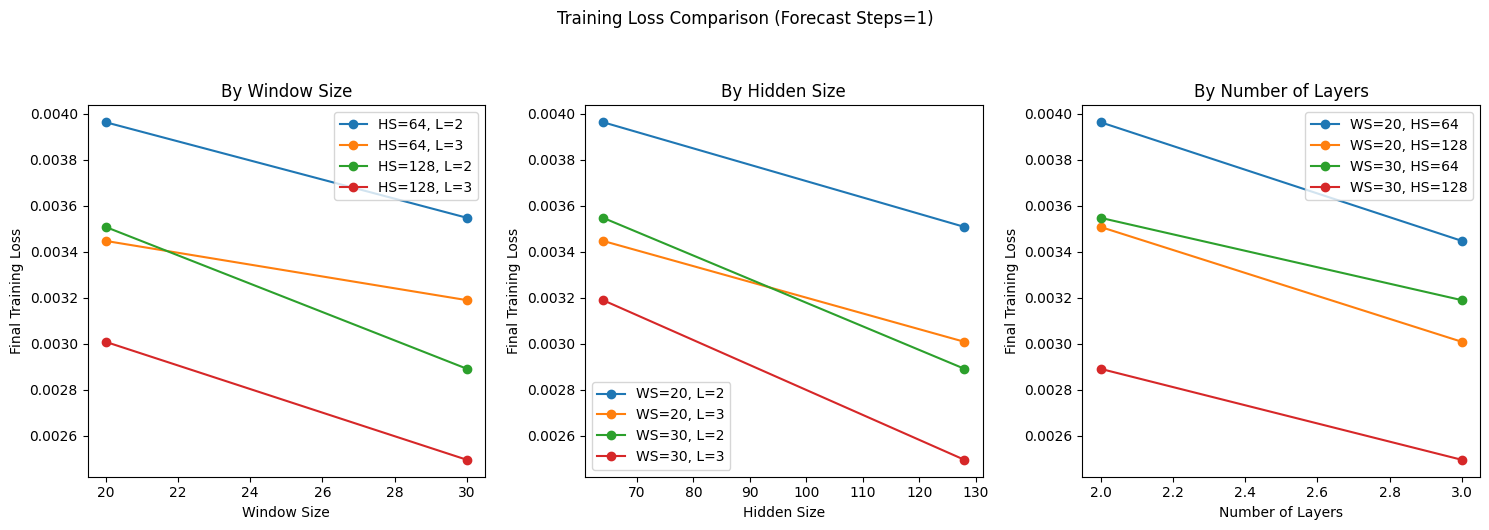

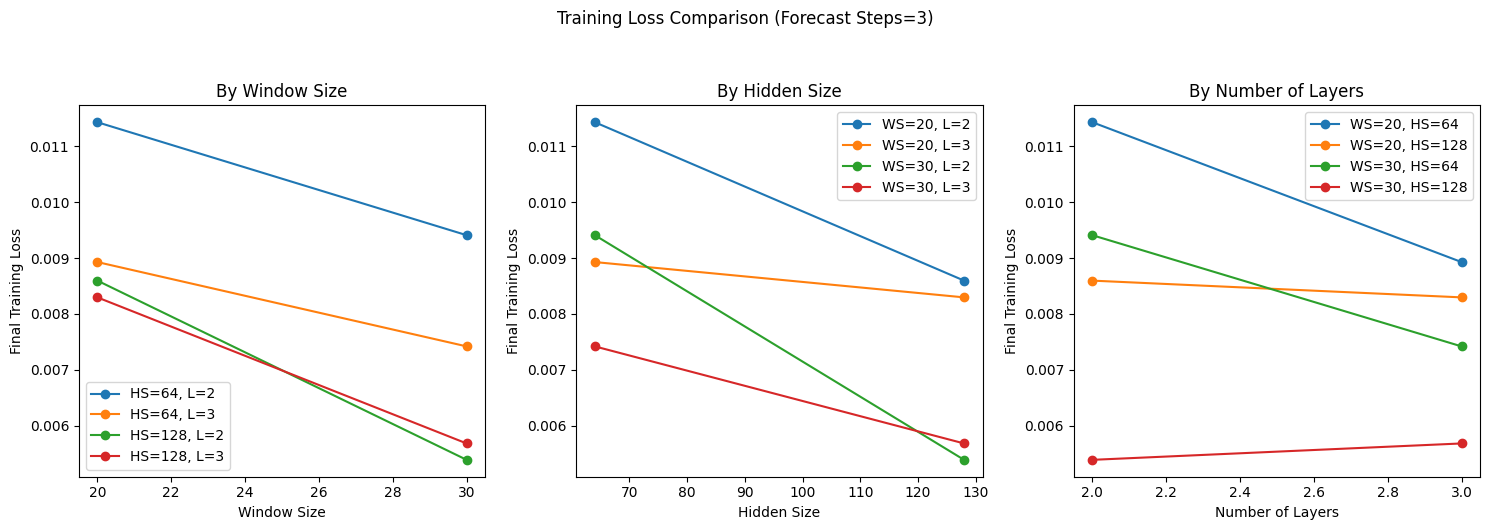

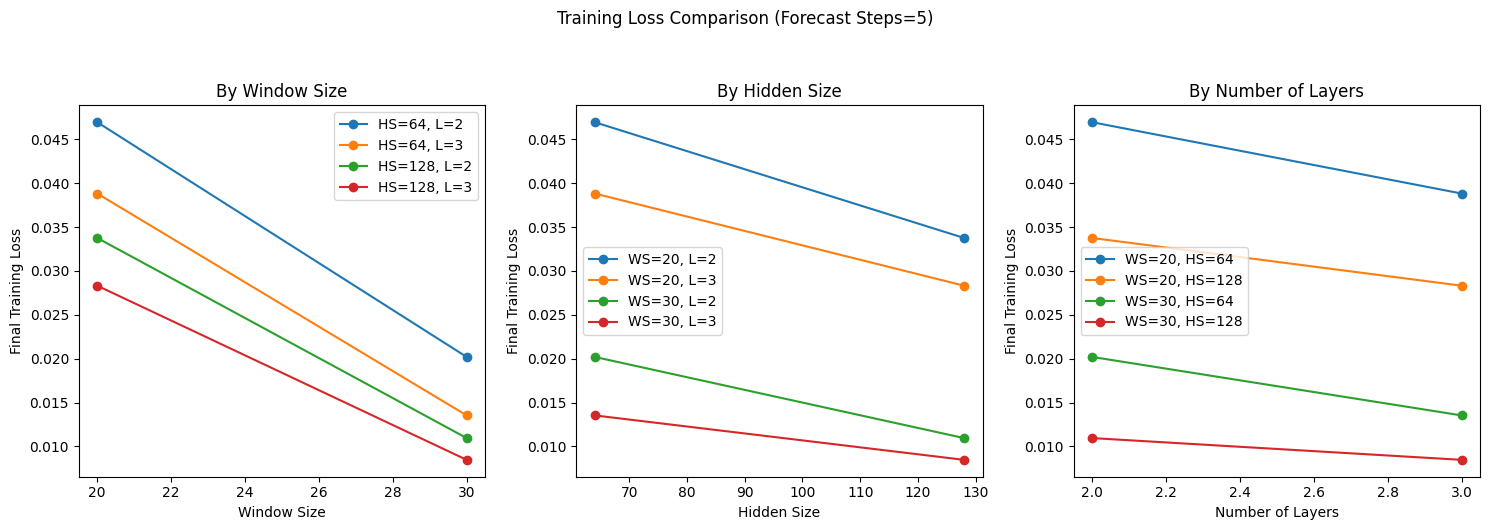

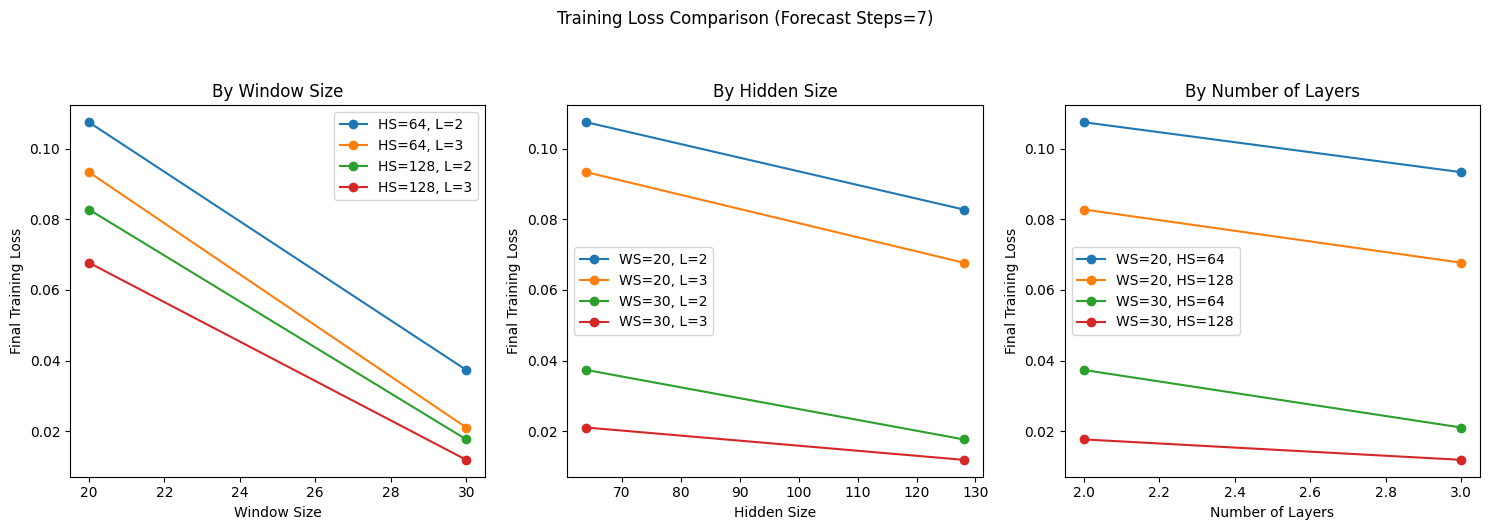

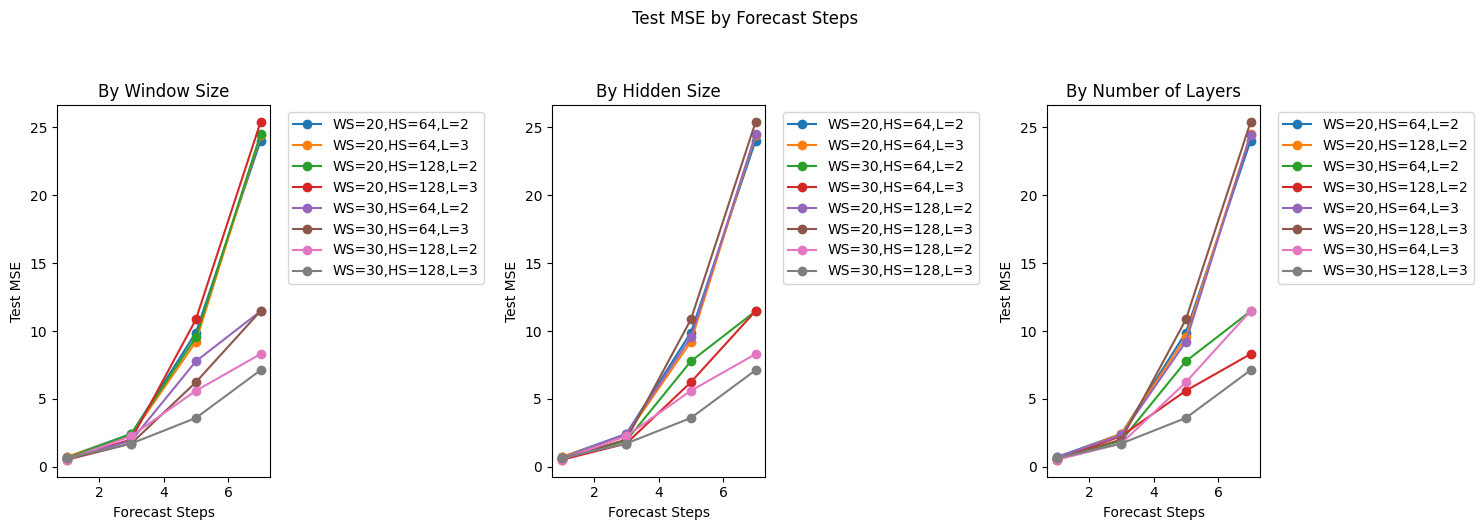


Comparative Results:
 window_size  hidden_size  num_layers  forecast_steps  final_train_loss  final_test_mse
          20           64           2               1          0.003964        0.710191
          20           64           2               3          0.011432        2.421475
          20           64           2               5          0.046940        9.884016
          20           64           2               7          0.107459       24.012205
          20           64           3               1          0.003448        0.716999
          20           64           3               3          0.008929        2.321526
          20           64           3               5          0.038815        9.212697
          20           64           3               7          0.093327       24.425219
          20          128           2               1          0.003509        0.625778
          20          128           2               3          0.008597        2.422068
          

In [4]:
if __name__ == '__main__':
    data_path = "/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt"  
    
    forecaster = MultiStepLSTMForecaster(
        data_path=data_path,
        window_sizes=[20, 30],  
        hidden_sizes=[64, 128],
        num_layers_list=[2, 3],
        forecast_steps=[1, 3, 5, 7],
        epochs=100,                       
        batch_size=32,                  
        lr=0.0001,                      
        results_dir='multi_step_lstm_results'  
    )
    
    results = forecaster.run_experiments()
    
    print("\nComparative Results:")
    print(results.to_string(index=False))

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GRUForecaster:
    def __init__(self, data_path, window_sizes=[10, 20, 30], hidden_sizes=[32, 64, 128], 
                 num_layers_list=[1, 2, 3], epochs=100, batch_size=32, lr=0.001, 
                 results_dir='gru_results'):
        self.data_path = data_path
        self.window_sizes = window_sizes
        self.hidden_sizes = hidden_sizes
        self.num_layers_list = num_layers_list
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.results_dir = results_dir
        os.makedirs(self.results_dir, exist_ok=True)
        
        self.load_and_normalize_data()
        
    class GRUModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.gru(x)
            out = out[:, -1, :] 
            out = self.fc(out)
            return out
    
    def load_and_normalize_data(self):
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        train_size = int(len(data) * 0.7)
        self.train_data = data[:train_size]
        self.test_data = data[train_size:]
        self.global_mean = self.train_data.mean()
        self.global_std = self.train_data.std()
        
    def prepare_data(self, window_size):
        train_data = (self.train_data - self.global_mean) / self.global_std
        test_data = (self.test_data - self.global_mean) / self.global_std
        
        extended_test_data = np.concatenate([
            train_data[-(window_size-1):], 
            test_data
        ])
        
        def create_samples(dataset):
            X, y = [], []
            for i in range(len(dataset)-window_size):
                X.append(dataset[i:i+window_size])
                y.append(dataset[i+window_size])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(extended_test_data)
        
        return (
            torch.from_numpy(X_train).float().view(-1, window_size, 1),
            torch.from_numpy(y_train).float().view(-1, 1),
            torch.from_numpy(X_test).float().view(-1, window_size, 1),
            torch.from_numpy(y_test).float().view(-1, 1)
        )

    def train_model(self, window_size, hidden_size, num_layers):
        X_train, y_train, X_test, y_test = self.prepare_data(window_size)
        
        model = self.GRUModel(1, hidden_size, num_layers).to(self.device)
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        
        train_dataset = TimeSeriesDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        config_str = f"ws{window_size}_hs{hidden_size}_nl{num_layers}"
        train_losses = []
        test_mses = []
        
        model.train()
        for epoch in tqdm(range(self.epochs), desc=f"WS{window_size} HS{hidden_size} L{num_layers}"):
            epoch_loss = 0
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_loss)
            
            if (epoch + 1) % 10 == 0 or epoch == self.epochs - 1:
                model.eval()
                with torch.no_grad():
                    test_mse = self.evaluate_model(model, X_test, y_test)
                test_mses.append(test_mse)
                model.train()
        
        self.save_results(config_str, model, train_losses, test_mses, X_test, y_test)
        
        return train_losses, test_mses[-1]

    def evaluate_model(self, model, X_test, y_test):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        return np.mean((predictions - actuals) ** 2)

    def save_results(self, config_str, model, train_losses, test_mses, X_test, y_test):
        config_dir = os.path.join(self.results_dir, config_str)
        os.makedirs(config_dir, exist_ok=True)
        
        loss_file = os.path.join(config_dir, 'training_losses.csv')
        pd.DataFrame({
            'epoch': range(1, len(train_losses)+1),
            'loss': train_losses
        }).to_csv(loss_file, index=False)
        
        test_mse_file = os.path.join(config_dir, 'test_mses.csv')
        pd.DataFrame({
            'epoch': [10*(i+1) for i in range(len(test_mses))],
            'test_mse': test_mses
        }).to_csv(test_mse_file, index=False)
        
        model_file = os.path.join(config_dir, 'model.pth')
        torch.save(model.state_dict(), model_file)
        
        self.generate_prediction_plot(model, X_test, y_test, config_str, config_dir)
        
        with open(os.path.join(config_dir, 'config_summary.txt'), 'w') as f:
            f.write(f"Window Size: {config_str.split('_')[0][2:]}\n")
            f.write(f"Hidden Size: {config_str.split('_')[1][2:]}\n")
            f.write(f"Num Layers: {config_str.split('_')[2][2:]}\n")
            f.write(f"Final Training Loss: {train_losses[-1]:.4f}\n")
            f.write(f"Final Test MSE: {test_mses[-1]:.4f}\n")

    def generate_prediction_plot(self, model, X_test, y_test, config_str, config_dir):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        
        plt.figure(figsize=(12, 6))
        plt.plot(actuals, label='Actual', alpha=0.7)
        plt.plot(predictions, label='Predicted', alpha=0.7)
        plt.title(f'GRU Predictions vs Actual - {config_str}')
        plt.legend()
        plot_file = os.path.join(config_dir, 'predictions_vs_actual.png')
        plt.savefig(plot_file)
        plt.close()

    def run_experiments(self):
        results = []
        
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                for nl in self.num_layers_list:
                    print(f"\nTraining GRU model with WS={ws}, HS={hs}, Layers={nl}")
                    config_str = f"ws{ws}_hs{hs}_nl{nl}"
                    
                    try:
                        final_loss, final_mse = self.train_model(ws, hs, nl)
                        results.append({
                            'window_size': ws,
                            'hidden_size': hs,
                            'num_layers': nl,
                            'final_train_loss': final_loss[-1],
                            'final_test_mse': final_mse
                        })
                    except Exception as e:
                        print(f"Failed to train {config_str}: {str(e)}")
                        continue
        
        results_df = pd.DataFrame(results)
        results_file = os.path.join(self.results_dir, 'comparative_results.csv')
        results_df.to_csv(results_file, index=False)
        
        self.generate_comparison_plots(results_df)
        
        return results_df

    def generate_comparison_plots(self, results_df):
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        for hs in self.hidden_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['hidden_size'] == hs) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['window_size'], subset['final_train_loss'], 
                            'o-', label=f'HS={hs}, L={nl}')
        plt.xlabel('Window Size')
        plt.ylabel('Final Training Loss')
        plt.title('GRU Training Loss by Window Size')
        plt.legend()
        
        plt.subplot(1, 3, 2)
        for ws in self.window_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['hidden_size'], subset['final_train_loss'], 
                            'o-', label=f'WS={ws}, L={nl}')
        plt.xlabel('Hidden Size')
        plt.ylabel('Final Training Loss')
        plt.title('GRU Training Loss by Hidden Size')
        plt.legend()
        
        plt.subplot(1, 3, 3)
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['hidden_size'] == hs)
                ]
                if not subset.empty:
                    plt.plot(subset['num_layers'], subset['final_train_loss'], 
                            'o-', label=f'WS={ws}, HS={hs}')
        plt.xlabel('Number of Layers')
        plt.ylabel('Final Training Loss')
        plt.title('GRU Training Loss by Number of Layers')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.results_dir, 'training_loss_comparison.png'))
        plt.show()
        plt.close()
        
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        for hs in self.hidden_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['hidden_size'] == hs) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['window_size'], subset['final_test_mse'], 
                            'o-', label=f'HS={hs}, L={nl}')
        plt.xlabel('Window Size')
        plt.ylabel('Test MSE')
        plt.title('GRU Test MSE by Window Size')
        plt.legend()
        
        plt.subplot(1, 3, 2)
        for ws in self.window_sizes:
            for nl in self.num_layers_list:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['num_layers'] == nl)
                ]
                if not subset.empty:
                    plt.plot(subset['hidden_size'], subset['final_test_mse'], 
                            'o-', label=f'WS={ws}, L={nl}')
        plt.xlabel('Hidden Size')
        plt.ylabel('Test MSE')
        plt.title('GRU Test MSE by Hidden Size')
        plt.legend()
        
        plt.subplot(1, 3, 3)
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                subset = results_df[
                    (results_df['window_size'] == ws) & 
                    (results_df['hidden_size'] == hs)
                ]
                if not subset.empty:
                    plt.plot(subset['num_layers'], subset['final_test_mse'], 
                            'o-', label=f'WS={ws}, HS={hs}')
        plt.xlabel('Number of Layers')
        plt.ylabel('Test MSE')
        plt.title('GRU Test MSE by Number of Layers')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.results_dir, 'test_mse_comparison.png'))
        plt.show()
        plt.close()


Training GRU model with WS=10, HS=32, Layers=1


WS10 HS32 L1: 100%|██████████| 100/100 [02:21<00:00,  1.41s/it]



Training GRU model with WS=10, HS=32, Layers=2


WS10 HS32 L2: 100%|██████████| 100/100 [02:46<00:00,  1.66s/it]



Training GRU model with WS=10, HS=32, Layers=3


...

WS30 HS128 L1: 100%|██████████| 100/100 [02:24<00:00,  1.45s/it]



Training GRU model with WS=30, HS=128, Layers=2


WS30 HS128 L2: 100%|██████████| 100/100 [02:48<00:00,  1.69s/it]



Training GRU model with WS=30, HS=128, Layers=3


WS30 HS128 L3: 100%|██████████| 100/100 [03:13<00:00,  1.94s/it]


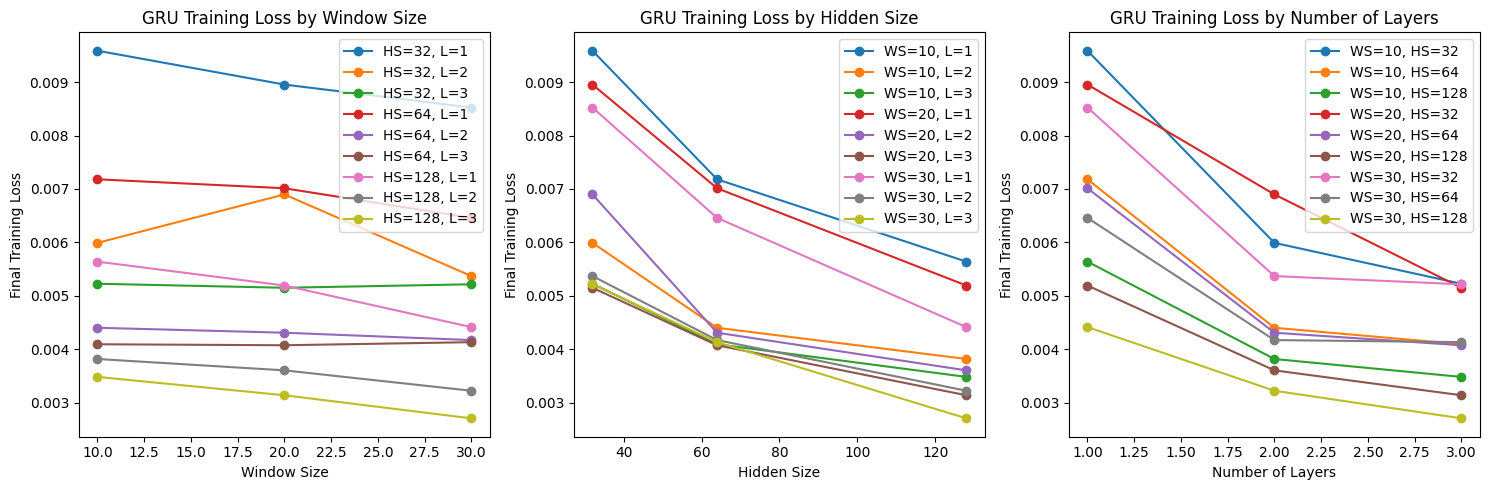

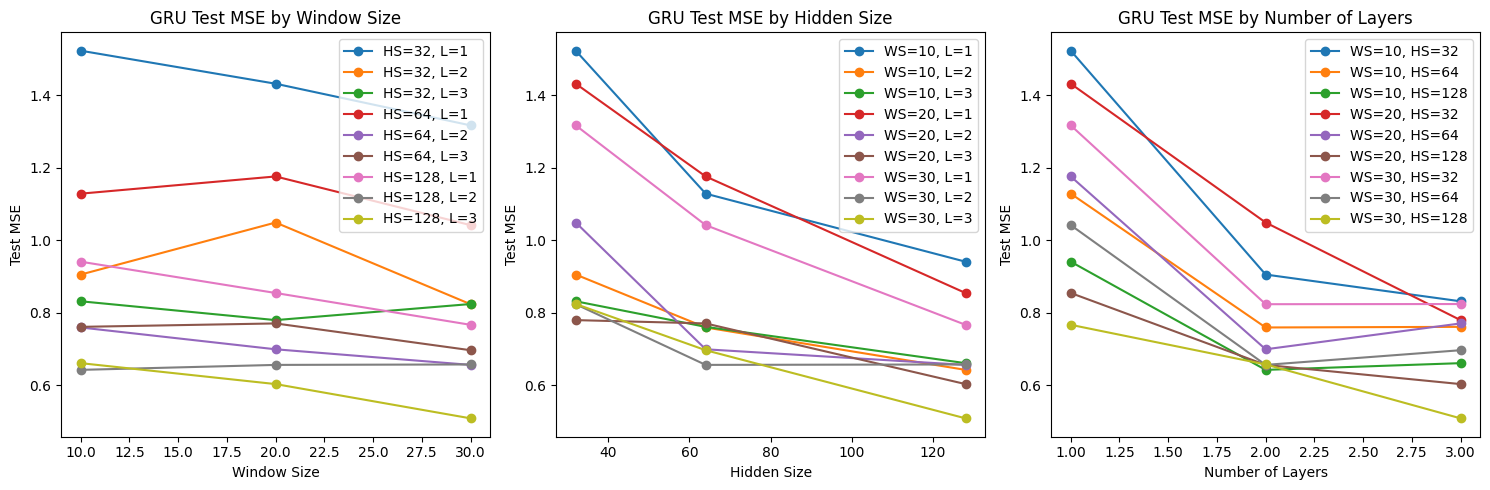


Comparative Results:
 window_size  hidden_size  num_layers  final_train_loss  final_test_mse
          10           32           1          0.009587        1.523642
          10           32           2          0.005990        0.905521
          10           32           3          0.005225        0.831679
          10           64           1          0.007180        1.128901
          10           64           2          0.004401        0.759364
          10           64           3          0.004093        0.761061
          10          128           1          0.005639        0.940990
          10          128           2          0.003817        0.642273
          10          128           3          0.003482        0.660818
          20           32           1          0.008954        1.432469
          20           32           2          0.006897        1.049192
          20           32           3          0.005150        0.779674
          20           64           1     

In [6]:
if __name__ == '__main__':
    data_path = "/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt" 
    forecaster = GRUForecaster(
        data_path=data_path,
        window_sizes=[10, 20, 30], 
        hidden_sizes=[32, 64, 128],
        num_layers_list=[1, 2, 3], 
        epochs=100,
        batch_size=32, 
        lr=0.0001, 
        results_dir='gru_results'
    )
    
    results = forecaster.run_experiments()
    
    print("\nComparative Results:")
    print(results.to_string(index=False))

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.metrics import mean_squared_error

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MultiStepGRUForecaster:
    def __init__(self, data_path, window_sizes=[10, 20, 30], hidden_sizes=[32, 64, 128], 
                 num_layers_list=[1, 2, 3], forecast_steps=[1, 3, 5], epochs=100, 
                 batch_size=32, lr=0.001, results_dir='multi_step_gru_results'):
        self.data_path = data_path
        self.window_sizes = window_sizes
        self.hidden_sizes = hidden_sizes
        self.num_layers_list = num_layers_list
        self.forecast_steps = forecast_steps
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.results_dir = results_dir
        os.makedirs(self.results_dir, exist_ok=True)
        
        self.load_and_normalize_data()
        
    class GRUModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, output_steps=1):
            super().__init__()
            self.output_steps = output_steps
            self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, output_steps)

        def forward(self, x):
            out, _ = self.gru(x)
            out = out[:, -1, :] 
            out = self.fc(out)
            return out.view(-1, self.output_steps)
    
    def load_and_normalize_data(self):
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        train_size = int(len(data) * 0.7)
        self.train_data = data[:train_size]
        self.test_data = data[train_size:]
        self.global_mean = self.train_data.mean()
        self.global_std = self.train_data.std()
        
    def prepare_data(self, window_size, forecast_steps):
        train_data = (self.train_data - self.global_mean) / self.global_std
        test_data = (self.test_data - self.global_mean) / self.global_std
        
        extended_test_data = np.concatenate([
            train_data[-(window_size + forecast_steps - 1):], 
            test_data
        ])
        
        def create_samples(dataset):
            X, y = [], []
            for i in range(len(dataset)-window_size-forecast_steps+1):
                X.append(dataset[i:i+window_size])
                y.append(dataset[i+window_size:i+window_size+forecast_steps])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(extended_test_data)
        
        return (
            torch.from_numpy(X_train).float().view(-1, window_size, 1),
            torch.from_numpy(y_train).float().view(-1, forecast_steps),
            torch.from_numpy(X_test).float().view(-1, window_size, 1),
            torch.from_numpy(y_test).float().view(-1, forecast_steps)
        )

    def train_model(self, window_size, hidden_size, num_layers, forecast_steps):
        X_train, y_train, X_test, y_test = self.prepare_data(window_size, forecast_steps)
        
        model = self.GRUModel(1, hidden_size, num_layers, forecast_steps).to(self.device)
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        
        train_dataset = TimeSeriesDataset(X_train, y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        config_str = f"ws{window_size}_hs{hidden_size}_nl{num_layers}_fs{forecast_steps}"
        train_losses = []
        test_mses = []
        
        model.train()
        for epoch in tqdm(range(self.epochs), desc=f"WS{window_size} HS{hidden_size} L{num_layers} FS{forecast_steps}"):
            epoch_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                optimizer.zero_grad()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_loss)
            
            if (epoch + 1) % 10 == 0 or epoch == self.epochs - 1:
                model.eval()
                with torch.no_grad():
                    test_mse = self.evaluate_model(model, X_test, y_test, forecast_steps)
                test_mses.append(test_mse)
                model.train()
        
        self.save_results(config_str, model, train_losses, test_mses, X_test, y_test, forecast_steps)
        
        return train_losses, test_mses[-1]

    def evaluate_model(self, model, X_test, y_test, forecast_steps):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        
        step_mses = [mean_squared_error(actuals[:, i], predictions[:, i]) 
                    for i in range(forecast_steps)]
        
        return np.mean(step_mses) 

    def save_results(self, config_str, model, train_losses, test_mses, X_test, y_test, forecast_steps):
        config_dir = os.path.join(self.results_dir, config_str)
        os.makedirs(config_dir, exist_ok=True)
        
        parts = config_str.split('_')
        ws = int(parts[0][2:])
        hs = int(parts[1][2:]) 
        nl = int(parts[2][2:]) 
        fs = int(parts[3][2:])
        
        pd.DataFrame({
            'epoch': range(1, len(train_losses)+1),
            'loss': train_losses
        }).to_csv(os.path.join(config_dir, 'training_losses.csv'), index=False)
        
        pd.DataFrame({
            'epoch': [10*(i+1) for i in range(len(test_mses))],
            'test_mse': test_mses
        }).to_csv(os.path.join(config_dir, 'test_mses.csv'), index=False)
        
        torch.save(model.state_dict(), os.path.join(config_dir, 'model.pth'))
        
        self.generate_prediction_plots(model, X_test, y_test, config_str, config_dir, forecast_steps)
        
        with open(os.path.join(config_dir, 'config_summary.txt'), 'w') as f:
            f.write(f"Window Size: {ws}\n")
            f.write(f"Hidden Size: {hs}\n")
            f.write(f"Num Layers: {nl}\n")
            f.write(f"Forecast Steps: {fs}\n")
            f.write(f"Final Training Loss: {train_losses[-1]:.4f}\n")
            f.write(f"Final Test MSE: {test_mses[-1]:.4f}\n")

    def generate_prediction_plots(self, model, X_test, y_test, config_str, config_dir, forecast_steps):
        test_dataset = TimeSeriesDataset(X_test, y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        
        predictions = np.array(predictions) * self.global_std + self.global_mean
        actuals = np.array(actuals) * self.global_std + self.global_mean
        
        plt.figure(figsize=(15, 5*forecast_steps))
        for step in range(forecast_steps):
            plt.subplot(forecast_steps, 1, step+1)
            plt.plot(actuals[:, step], label='Actual', alpha=0.7)
            plt.plot(predictions[:, step], label='Predicted', alpha=0.7)
            plt.title(f'Step {step+1} Predictions vs Actual - {config_str}')
            plt.legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(config_dir, 'predictions_vs_actual.png'))
        plt.close()

    def run_experiments(self):
        results = []
        
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                for nl in self.num_layers_list:
                    for fs in self.forecast_steps:
                        print(f"\nTraining GRU model with WS={ws}, HS={hs}, Layers={nl}, FS={fs}")
                        config_str = f"ws{ws}_hs{hs}_nl{nl}_fs{fs}"
                        
                        try:
                            final_loss, final_mse = self.train_model(ws, hs, nl, fs)
                            results.append({
                                'window_size': ws,
                                'hidden_size': hs,
                                'num_layers': nl,
                                'forecast_steps': fs,
                                'final_train_loss': final_loss[-1],
                                'final_test_mse': final_mse
                            })
                        except Exception as e:
                            print(f"Failed to train {config_str}: {str(e)}")
                            continue
        
        results_df = pd.DataFrame(results)
        print("Results DataFrame columns:", results_df.columns) 
        print("Results DataFrame content:\n", results_df) 
        
        results_file = os.path.join(self.results_dir, 'comparative_results.csv')
        results_df.to_csv(results_file, index=False)
        
        if not results_df.empty: 
            self.generate_comparison_plots(results_df)
        
        return results_df

    def generate_comparison_plots(self, results_df):
        
        self._generate_hyperparam_plots(results_df, 'final_train_loss', 'Training Loss')
        
        self._generate_hyperparam_plots(results_df, 'final_test_mse', 'Test MSE')
        
        plt.figure(figsize=(12, 6))
        for ws in self.window_sizes:
            for hs in self.hidden_sizes:
                for nl in self.num_layers_list:
                    subset = results_df[
                        (results_df['window_size'] == ws) & 
                        (results_df['hidden_size'] == hs) & 
                        (results_df['num_layers'] == nl)
                    ]
                    if not subset.empty:
                        plt.plot(subset['forecast_steps'], subset['final_test_mse'], 
                                'o-', label=f'WS={ws},HS={hs},L={nl}')
        
        plt.xlabel('Forecast Steps')
        plt.ylabel('Test MSE')
        plt.title('GRU Test MSE by Forecast Steps')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(os.path.join(self.results_dir, 'test_mse_vs_forecast_steps.png'))
        plt.show()
        plt.close()

    def _generate_hyperparam_plots(self, results_df, metric, title):
        required_columns = ['window_size', 'hidden_size', 'num_layers', 'forecast_steps', metric]
        if not all(col in results_df.columns for col in required_columns):
            print(f"Warning: Missing required columns in results DataFrame. Available columns: {results_df.columns}")
            return
        
        for fs in self.forecast_steps:
            plt.figure(figsize=(15, 5))
            plt.suptitle(f'GRU {title} Comparison (Forecast Steps={fs})', y=1.05)
            
            plt.subplot(1, 3, 1)
            for hs in self.hidden_sizes:
                for nl in self.num_layers_list:
                    subset = results_df[
                        (results_df['hidden_size'] == hs) & 
                        (results_df['num_layers'] == nl) &
                        (results_df['forecast_steps'] == fs)
                    ]
                    if not subset.empty:
                        plt.plot(subset['window_size'], subset[metric], 
                                'o-', label=f'HS={hs}, L={nl}')
            plt.xlabel('Window Size')
            plt.ylabel(title)
            plt.title('By Window Size')
            plt.legend()
            
            plt.subplot(1, 3, 2)
            for ws in self.window_sizes:
                for nl in self.num_layers_list:
                    subset = results_df[
                        (results_df['window_size'] == ws) & 
                        (results_df['num_layers'] == nl) &
                        (results_df['forecast_steps'] == fs)
                    ]
                    if not subset.empty:
                        plt.plot(subset['hidden_size'], subset[metric], 
                                'o-', label=f'WS={ws}, L={nl}')
            plt.xlabel('Hidden Size')
            plt.ylabel(title)
            plt.title('By Hidden Size')
            plt.legend()
            
            plt.subplot(1, 3, 3)
            for ws in self.window_sizes:
                for hs in self.hidden_sizes:
                    subset = results_df[
                        (results_df['window_size'] == ws) & 
                        (results_df['hidden_size'] == hs) &
                        (results_df['forecast_steps'] == fs)
                    ]
                    if not subset.empty:
                        plt.plot(subset['num_layers'], subset[metric], 
                                'o-', label=f'WS={ws}, HS={hs}')
            plt.xlabel('Number of Layers')
            plt.ylabel(title)
            plt.title('By Number of Layers')
            plt.legend()
            
            plt.tight_layout()
            plt.savefig(os.path.join(self.results_dir, f'{metric.lower()}_comparison_fs{fs}.png'))
            plt.show()
            plt.close()


Training GRU model with WS=20, HS=64, Layers=2, FS=1


WS20 HS64 L2 FS1: 100%|██████████| 100/100 [02:50<00:00,  1.71s/it]



Training GRU model with WS=20, HS=64, Layers=2, FS=3


WS20 HS64 L2 FS3: 100%|██████████| 100/100 [02:49<00:00,  1.70s/it]



Training GRU model with WS=20, HS=64, Layers=2, FS=5


...


Training GRU model with WS=30, HS=128, Layers=3, FS=5


WS30 HS128 L3 FS5: 100%|██████████| 100/100 [03:16<00:00,  1.96s/it]



Training GRU model with WS=30, HS=128, Layers=3, FS=7


WS30 HS128 L3 FS7: 100%|██████████| 100/100 [03:16<00:00,  1.97s/it]


Results DataFrame columns: Index(['window_size', 'hidden_size', 'num_layers', 'forecast_steps',
       'final_train_loss', 'final_test_mse'],
      dtype='object')
Results DataFrame content:
     window_size  hidden_size  num_layers  forecast_steps  final_train_loss  \
0            20           64           2               1          0.004092   
1            20           64           2               3          0.013201   
2            20           64           2               5          0.054875   
3            20           64           2               7          0.122386   
4            20           64           3               1          0.003957   
5            20           64           3               3          0.010579   
6            20           64           3               5          0.040268   
7            20           64           3               7          0.106739   
8            20          128           2               1          0.003526   
9            20          128

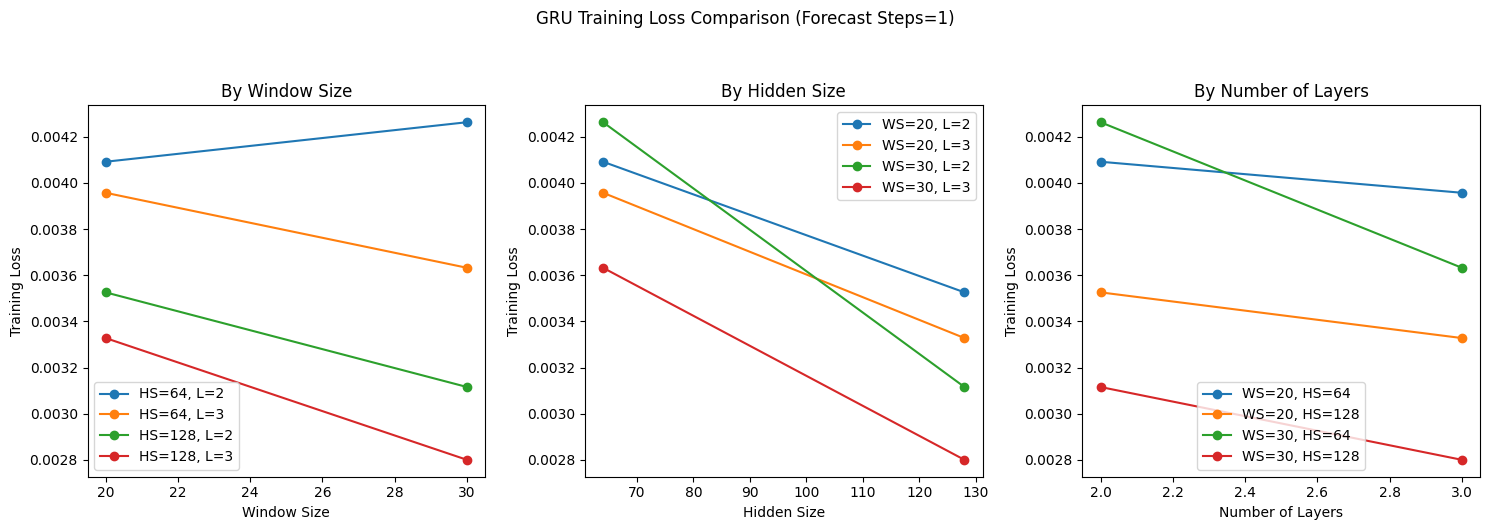

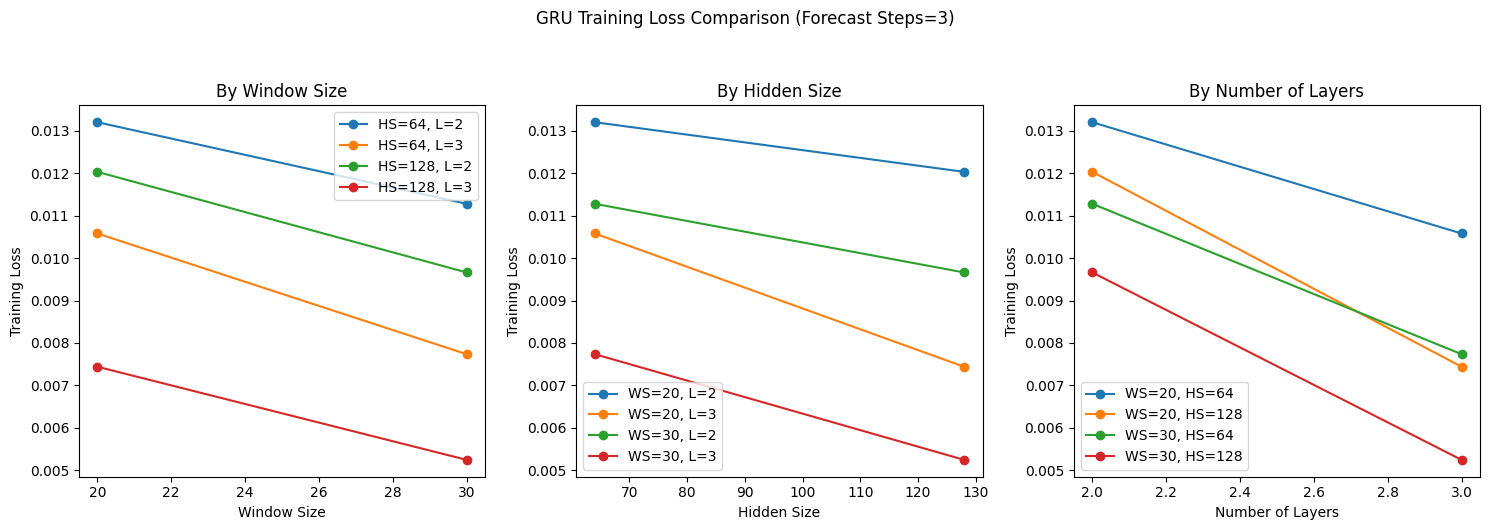

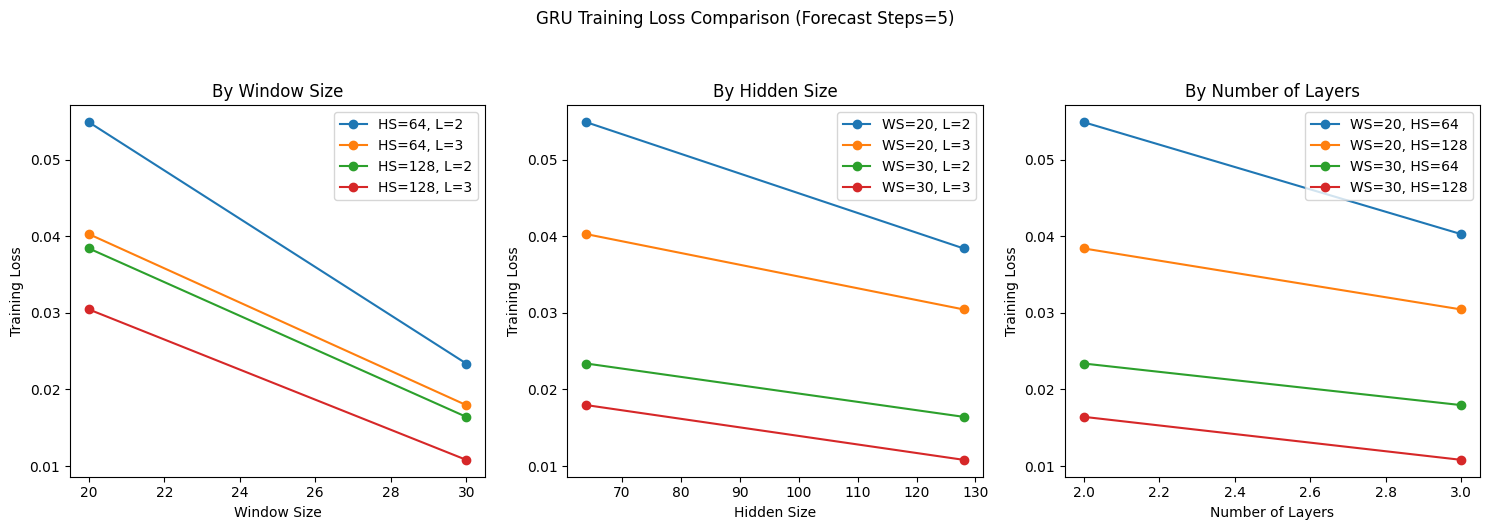

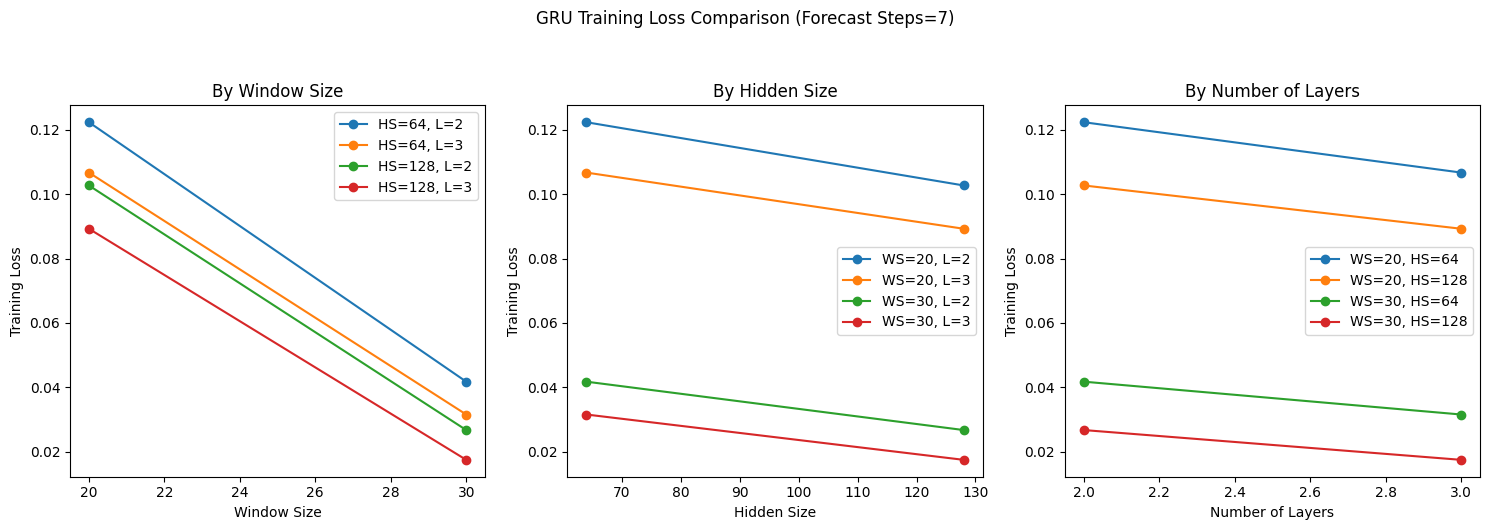

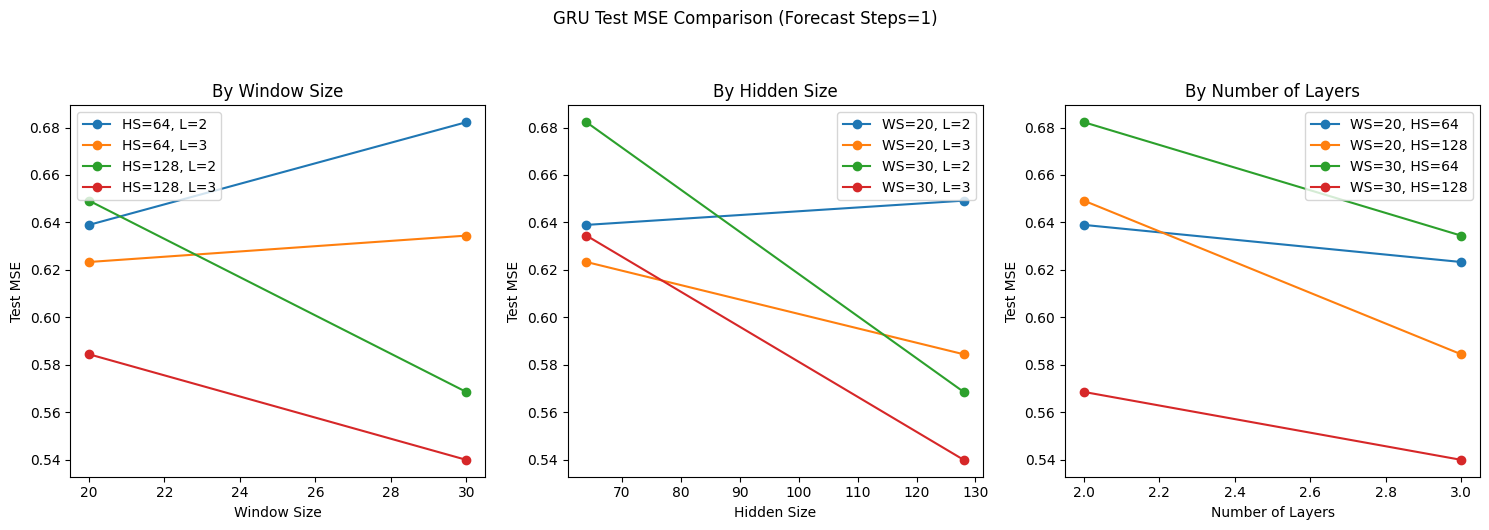

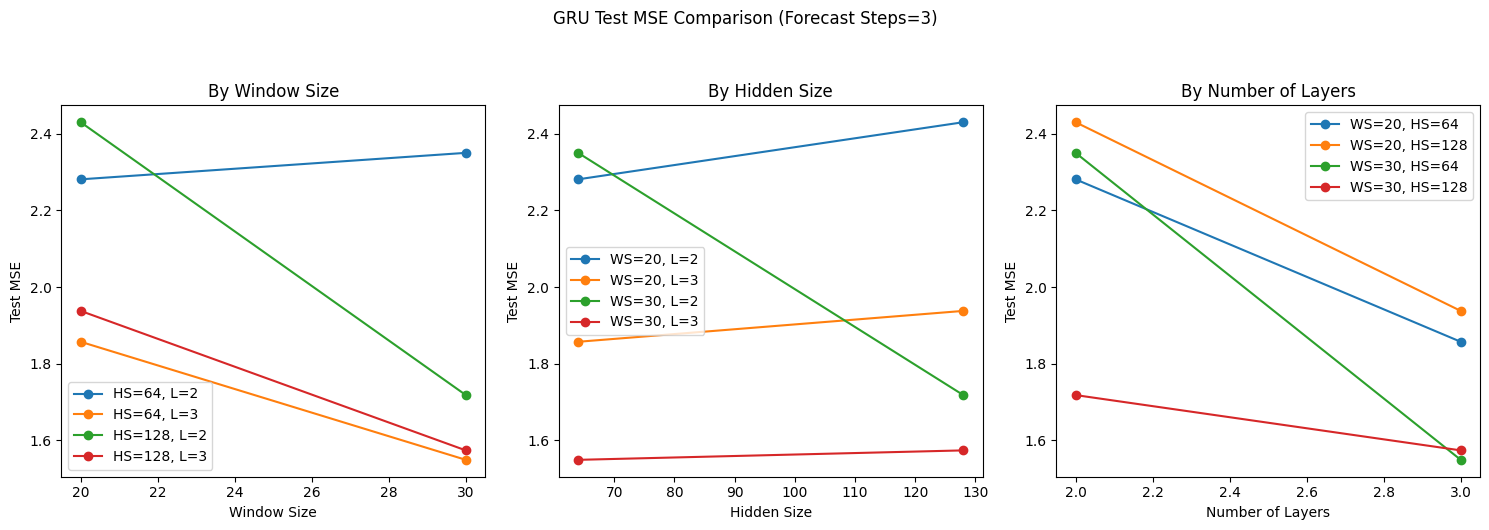

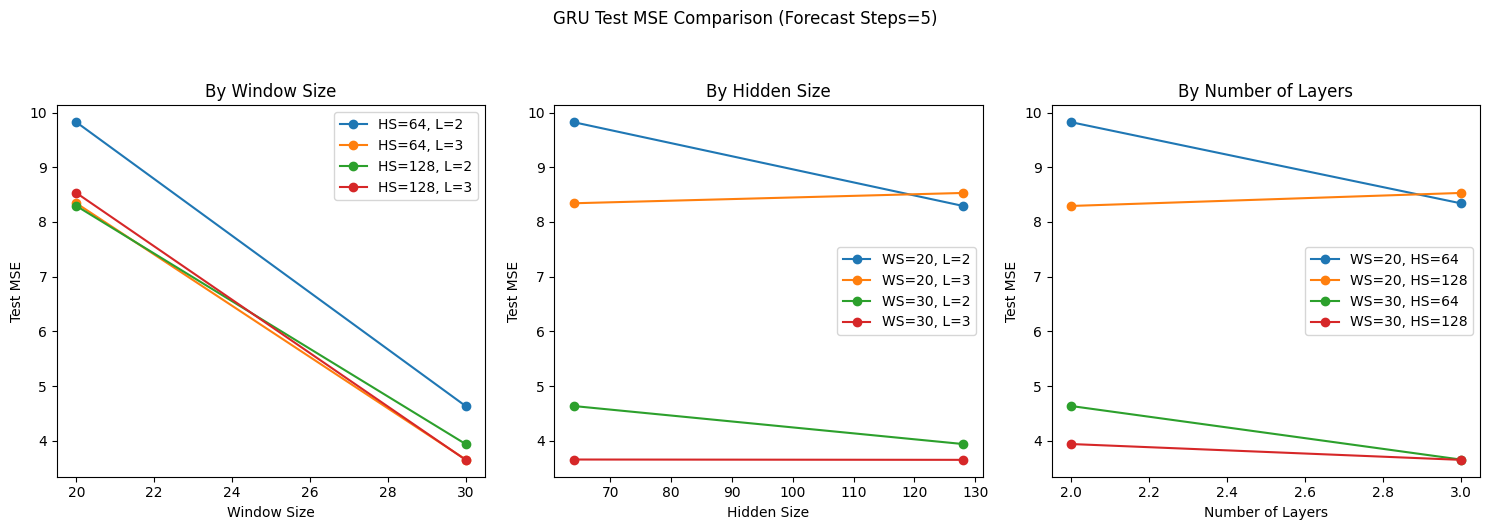

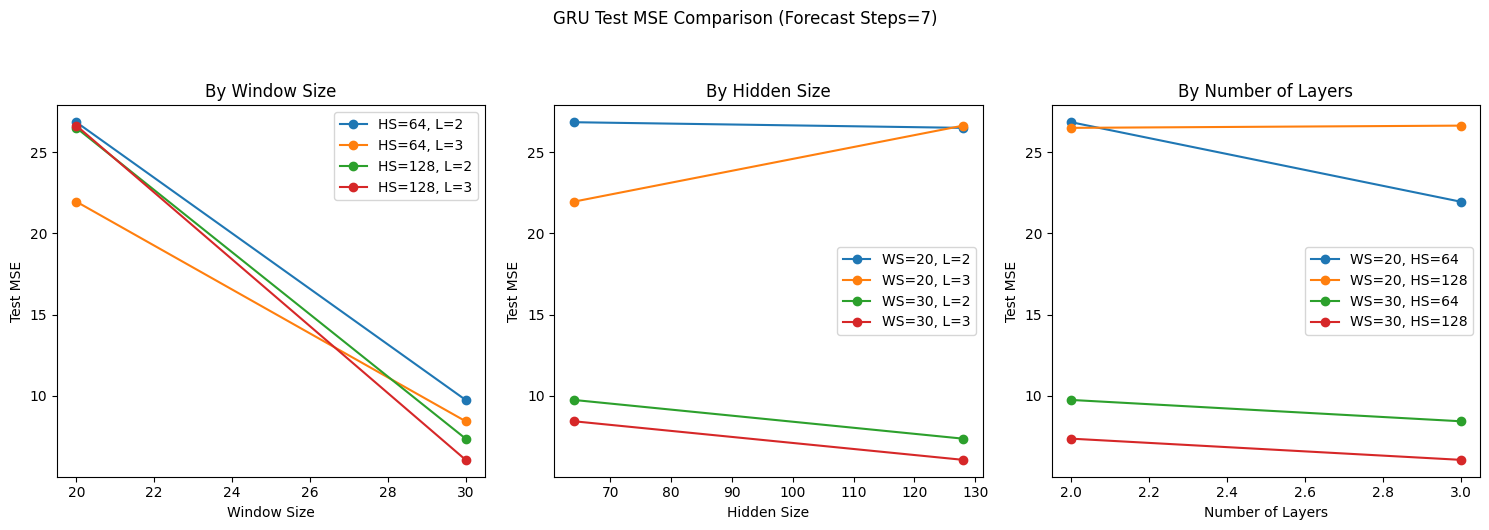

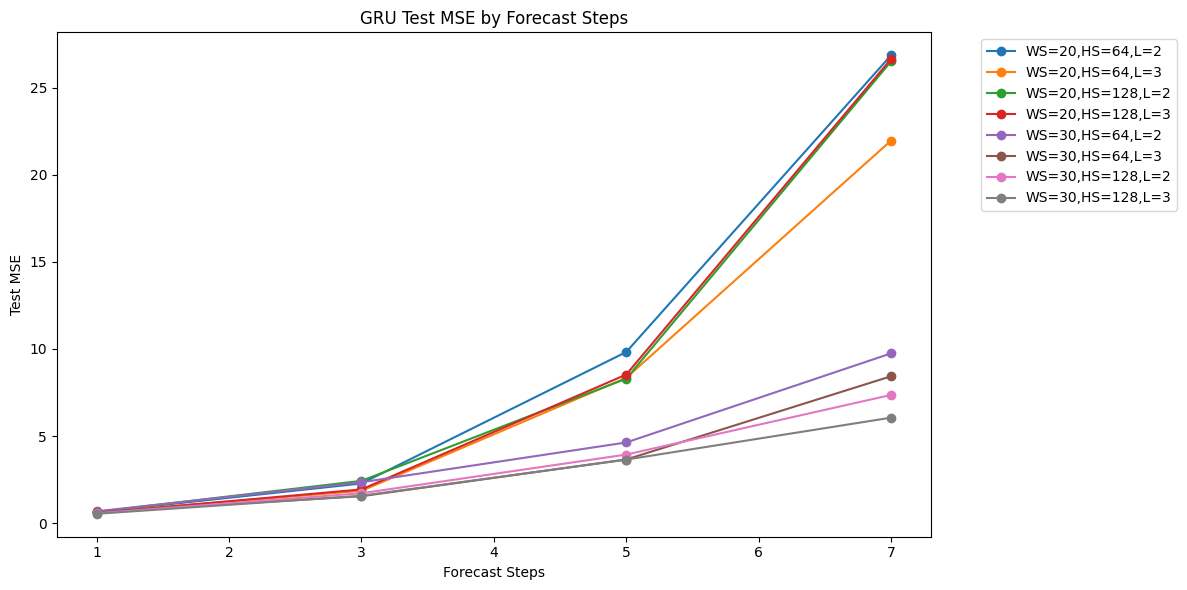


Comparative Results:
 window_size  hidden_size  num_layers  forecast_steps  final_train_loss  final_test_mse
          20           64           2               1          0.004092        0.638970
          20           64           2               3          0.013201        2.280854
          20           64           2               5          0.054875        9.824806
          20           64           2               7          0.122386       26.853075
          20           64           3               1          0.003957        0.623333
          20           64           3               3          0.010579        1.857279
          20           64           3               5          0.040268        8.342415
          20           64           3               7          0.106739       21.958834
          20          128           2               1          0.003526        0.649185
          20          128           2               3          0.012032        2.429786
          

In [8]:
if __name__ == '__main__':
    data_path = "/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt"  
    
    forecaster = MultiStepGRUForecaster(
        data_path=data_path,
        window_sizes=[20, 30],
        hidden_sizes=[64, 128],
        num_layers_list=[2, 3],
        forecast_steps=[1, 3, 5, 7],
        epochs=100,
        batch_size=32,
        lr=0.0001,
        results_dir='multi_step_gru_results'
    )
    
    results = forecaster.run_experiments()
    
    print("\nComparative Results:")
    print(results.to_string(index=False))